In [2]:
import json

from protest_impact.util import project_root

with open(project_root / "data" / "protest" / "predictions.jsonl") as f:
    predictions = [json.loads(line) for line in f]

with open(project_root / "data" / "news" / "protest_news_shuffled_v2.jsonl") as f:
    news = [json.loads(line) for line in f]

In [16]:
protest_news = []
for prediction, article in zip(predictions, news):
    if prediction["label"] == "LABEL_1":
        for k, v in article["meta"].items():
            article[k] = v
        del article["meta"]
        article["score"] = prediction["score"]
        protest_news.append(article)

In [17]:
protest_news.sort(key=lambda x: x["score"], reverse=True)

In [18]:
protest_news[:5]

[{'text': '[Berliner Taxifahrer begrüßen BER zum Start mit Hupkonzert - B.Z. - Die Stimme Berlins]\n\nIn einer langen Kolonne ziehen Taxifahrer zum neuen Hauptstadtflughafen (Foto: picture alliance/dpa)\n\nRund 700 starteten am Vormittag nach Angaben der Organisatoren zu einer Sternfahrt am Flughafen Tegel im Nordwesten Berlins, etwa 300 stießen in weiteren Teilen Berlins zu dem Korso. 50 Taxen durften direkt vor dem Terminal 1 vorfahren und nutzten die Gelegenheit für ein Hupkonzert.\n\nDie Taxidemo auf dem Weg zum BER (Foto: Olaf Wagner)\n\n„Wir wollen, dass alle Berliner Taxen Laderecht am BER bekommen“, sagte Initiator Erkan Özmen. „Wir machen Druck auf Verkehrssenatorin Regine Günther. Es ist nicht gut, wie sie mit uns umgeht.“\n\nDie Taxifahrer verlangen, dass Günther sich mit der bisherigen Regelung nicht zufrieden gibt. Aktuell dürfen nur 300 Berliner Taxen in Schönefeld Gäste mitnehmen. „Wir werden sehen, ob weitere Demonstrationen nötig sind“, sagte Özmen.\n\nTaxen am Termina

In [19]:
protest_news[-5:]

[{'text': '[Disco ohne Ende: Streit über Nachtlärm in Bulgariens Badeorten]\n\n# Disco ohne Ende: Streit über Nachtlärm in Bulgariens Badeorten\n\nErstellt: 16.08.2017, 14:41 Uhr\n\n\nDiskothek © dpa\n\nIn den Lokalen an Bulgariens Schwarzmeerküste soll es nach dem Willen der Regierung keine lauten Partys bis zum Morgen mehr geben. Die Tourismus-Branche weigert sich.\n\nSofia - Hunderte Beschäftigte bei den Lokalen in Slantschew Brjag (Sonnenstrand) forderten bei einem Protest am Mittwoch den Rücktritt des für den Tourismus zuständigen Vizeregierungschefs Waleri Simeonow, wie der private Fernsehsender BIP berichtete. Geplant seien weitere Proteste.\n\nZum Konflikt mit der Tourismus-Branche kam es nach Simeonows nächtlichen Kontrollen in dem größten bulgarischen Urlaubsort Slantschew Brjag am vergangenen Wochenende. Dabei wurde in den betroffenen Discos Medienberichten zufolge die lautstarke Musik ausgeschaltet. Ein DJ wurde vorübergehend festgenommen, da er verhindert habe, dass die Po

In [21]:
protest_news[-505:-500]

[{'text': '[Sicherheitskräfte: Friedrich Merz sieht keinen latenten Rassismus bei der Polizei | ZEIT ONLINE]\n\nDer ehemalige Fraktionschef der CDU, Friedrich Merz, hat davor gewarnt, in der Diskussion um Rassismus die Situation in Deutschland mit der in den USA zu vergleichen. Er halte es für unzulässig, "die Bilder aus Amerika eins zu eins auf Deutschland zu übertragen", sagte er den Zeitungen der Funke Mediengruppe. "Die Amerikaner haben seit der Abschaffung der Sklaverei das Problem der Rassendiskriminierung bis heute nicht wirklich gelöst. In Deutschland gibt es das in dieser Form nicht – und es gibt bei uns auch keinen latenten Rassismus bei der Polizei."\n\nLaut Merz hat US-Präsident Donald Trump die Proteste in den USA verstärkt. In den vergangenen Jahren habe es schon breite Proteste nach ähnlichen Vorfällen wie dem Tod von George Floyd gegeben. "Wahrscheinlich wären die Demonstrationen aber auch dieses Mal im bekannten Rahmen geblieben, wenn nicht der Präsident so viel Öl ins

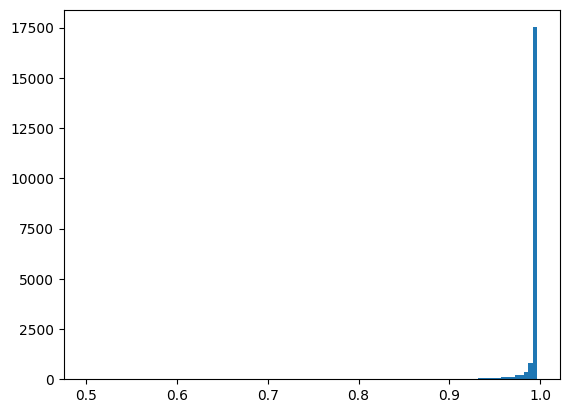

In [20]:
# plot distribution of scores
import matplotlib.pyplot as plt
import numpy as np

scores = [article["score"] for article in protest_news]
plt.hist(scores, bins=100)
plt.show()

In [22]:
with open(project_root / "data" / "protest" / "protest_news_predicted.jsonl", "w") as f:
    for article in protest_news:
        f.write(json.dumps(article) + "\n")